In [1]:
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    VecFrameStack,
    VecEnvWrapper
)
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import json
import time
from collections import defaultdict

gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Inspect the environment 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space: ", env.observation_space)
print("Act space: ", env.action_space)
print("Actions:   ", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:          ", ale.lives())
print("Frame number:   ", ale.getFrameNumber())
print("Episode frames: ", ale.getEpisodeFrameNumber())
print("RAM size:       ", len(ale.getRAM()))
print("Legal actions:  ", ale.getLegalActionSet())
print("Min actions:    ", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space:  Box(0, 255, (210, 160, 3), uint8)
Act space:  Discrete(9)
Actions:    ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives:           3
Frame number:    0
Episode frames:  0
RAM size:        128
Legal actions:   [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions:     [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


Reward Shaping Wrapper

In [ ]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARD = {200, 400, 800, 1600}
    FRUIT_REWARD = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150

    def __init__(self, env,
                 ghost_chain_bonus=12.0,
                 ghost_hunt_bonus=0.0,
                 missed_ghost_penalty=0.0,
                 timing_bonus=0.0,
                 pellet_streak_bonus=0.03,
                 fruit_multiplier=1.05, 
                 death_penalty=0.0,):
        super().__init__(env)
        self.ghost_chain_bonus     = ghost_chain_bonus
        self.ghost_hunt_bonus      = ghost_hunt_bonus
        self.missed_ghost_penalty  = missed_ghost_penalty
        self.timing_bonus    = timing_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty    = death_penalty
       
        # State tracking for reward shaping
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward 
 
        # Initialise lives tracker 
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power pellet tracking
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                if self.ghosts_eaten == 0:
                    shaped_reward += self.missed_ghost_penalty * 2
                elif self.ghosts_eaten == 1:
                    shaped_reward += self.missed_ghost_penalty
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0

        # Ghost eaten
        if reward in self.GHOST_REWARD:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
            if self._power_pellet_active:
                    shaped_reward += self.ghost_hunt_bonus

        raw_reward = int(reward)
        # Pellet streak
        if raw_reward == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
        elif raw_reward == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0

            shaped_reward += self.pellet_streak_bonus * self._pellet_streak

            # Start pellet timer
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
        else:
            self._steps_since_pellet += 1

            # Break if too much without eating a pellet
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0

        # Fruit multiplier
        if raw_reward in self.FRUIT_REWARD:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw_reward

        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
 
        return obs, shaped_reward, terminated, truncated, info

Define the 4 Experimental Conditions

In [ ]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "#4C9BE8",
        "description": "Default ALE rewards only"
    },

    "Death Penalty": {
        "wrapper": "simple",
        "survival_bonus": 0.0, 
        "death_penalty": -5.0,
        "power_pellet_bonus": 0.0,
        "color": "#57C97A",
        "description": "-5 on each life lost"
    },

    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "ghost_hunt_bonus": 0.0,
        "missed_ghost_penalty": 0.0,
        "timing_bonus": 0.0,
        "pellet_streak_bonus": 0.3,
        "fruit_multiplier": 1.5, 
        "death_penalty": -5.0,    
        "color": "#C97AE8",
        "description": "Expert: chain + streak + fruit + small penalty"
    },

   "Expert No Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus":    12.0, 
        "ghost_hunt_bonus":      0.0,
        "missed_ghost_penalty":  0.0,
        "timing_bonus":          0.0,
        "pellet_streak_bonus":   0.3,
        "fruit_multiplier":      1.5,
        "death_penalty":         0.0, 
        "color": "#E8C94C",
        "description": "Expert signals only, no death penalty"
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:20s} — {cfg['description']}")

Conditions defined:
  Baseline             — Default ALE rewards only
  Death Penalty        — -25 on each life lost
  Expert Shaping       — Ghost chain + pellet streak +fruit + death penalty
  Expert No Death Penalty — Ghost chain + pellet streak +fruit, no death penalty


Progress Callback (tracks metrics per episode)

In [6]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose=0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0
 
    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
 
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
            if len(self.episode_rewards) % 50 == 0:
                recent_r = np.mean(self.episode_rewards[-20:])
                recent_l = np.mean(self.episode_lengths[-20:])
                print(f"  [{self.condition_name}] "
                      f"Ep {len(self.episode_rewards):>4} | "
                      f"Steps {self.num_timesteps:>7,} | "
                      f"Avg reward: {recent_r:>7.1f} | "
                      f"Avg length: {recent_l:>5.0f}")
        return True
 

Training Function

In [ ]:
from xml.parsers.expat import model

def make_env(condition_name, condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5")
        env.reset(seed=seed)
        if condition_cfg["wrapper"] == None:
            pass
        elif condition_cfg["wrapper"] == "simple":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus=0.0,
                ghost_hunt_bonus=0.0,
                missed_ghost_penalty=0.0,
                timing_bonus=0.0,
                pellet_streak_bonus=0.0,
                fruit_multiplier=1.0,
                death_penalty=condition_cfg.get("death_penalty", 0.0),

            )
        elif condition_cfg["wrapper"] == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
                ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
                missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
                timing_bonus=condition_cfg.get("timing_bonus", 0.0),
                pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty=condition_cfg.get("death_penalty", 0.0),
            )
        
        env = AtariWrapper(env, clip_reward=False)
        return env
    return _init
 
def train_condition(condition_name, condition_cfg, total_timesteps=1000000, seed=42):
    print(f"\n{'='*60}")
    print(f"Training: {condition_name}")
    print(f"Config:   {condition_cfg['description']}")
    print(f"Steps:    {total_timesteps:,}")

    vec_env = DummyVecEnv([make_env(condition_name, condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)

    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps=128,
        batch_size=256,
        n_epochs=4,
        gamma=0.99,
        learning_rate=2.5e-4,
        clip_range=0.1,
        verbose=0,
        seed=seed,
    )

    callback = ExperimentCallback(condition_name)

    model.learn(total_timesteps=total_timesteps, callback=callback)
    steps_str = f"{total_timesteps // 1_000_000}M"
    save_path = f"ppo_pacman_{condition_name.replace(' ', '_').lower()}_{steps_str}"
    model.save(save_path)
    print(f"  Saved to {save_path}.zip")
    
    vec_env.close()
    return model, callback

In [ ]:
TOTAL_STEPS = 1_000_000
 
results = {} 
 
for name, cfg in CONDITIONS.items():
    try:
        model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
        results[name] = {
            "callback": callback,
            "model": model,
            "episode_rewards": callback.episode_rewards,
            "episode_lengths": callback.episode_lengths,
            "total_steps": TOTAL_STEPS,
        }
        print(f"  Completed training for {name}.")
    except Exception as e:
        print(f"  Error during training for {name}: {e}")
        results[name] = None
 
print(f"\nAll conditions trained! {TOTAL_STEPS:,} steps each.")


Training: Baseline
Config:   Default ALE rewards only


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps   2,442 | Avg reward:   199.0 | Avg length:    57
  [Baseline] Ep  100 | Steps   5,198 | Avg reward:   136.0 | Avg length:    54
  [Baseline] Ep  150 | Steps   7,854 | Avg reward:   131.5 | Avg length:    50
  [Baseline] Ep  200 | Steps  10,574 | Avg reward:   166.5 | Avg length:    49
  [Baseline] Ep  250 | Steps  13,221 | Avg reward:   186.0 | Avg length:    55
  [Baseline] Ep  300 | Steps  15,885 | Avg reward:   156.0 | Avg length:    55
  [Baseline] Ep  350 | Steps  18,519 | Avg reward:   196.5 | Avg length:    58
  [Baseline] Ep  400 | Steps  21,117 | Avg reward:   152.0 | Avg length:    51
  [Baseline] Ep  450 | Steps  23,688 | Avg reward:   135.0 | Avg length:    50
  [Baseline] Ep  500 | Steps  25,940 | Avg reward:   109.0 | Avg length:    47
  [Baseline] Ep  550 | Steps  28,506 | Avg reward:   256.0 | Avg length:    57
  [Baseline] Ep  600 | Steps  31,236 | Avg reward:   408.0 | Avg length:    56
  [Baseline] Ep  650 | Steps  33,602 | Avg reward:  

g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Death Penalty] Ep   50 | Steps   2,504 | Avg reward:   136.3 | Avg length:    50
  [Death Penalty] Ep  100 | Steps   4,952 | Avg reward:   196.9 | Avg length:    51
  [Death Penalty] Ep  150 | Steps   7,490 | Avg reward:   143.9 | Avg length:    50
  [Death Penalty] Ep  200 | Steps   9,983 | Avg reward:   157.1 | Avg length:    50
  [Death Penalty] Ep  250 | Steps  12,881 | Avg reward:   103.9 | Avg length:    57
  [Death Penalty] Ep  300 | Steps  15,291 | Avg reward:   178.6 | Avg length:    49
  [Death Penalty] Ep  350 | Steps  18,095 | Avg reward:   168.7 | Avg length:    54
  [Death Penalty] Ep  400 | Steps  20,731 | Avg reward:   136.6 | Avg length:    53
  [Death Penalty] Ep  450 | Steps  23,061 | Avg reward:    59.5 | Avg length:    43
  [Death Penalty] Ep  500 | Steps  25,656 | Avg reward:   251.4 | Avg length:    55
  [Death Penalty] Ep  550 | Steps  28,205 | Avg reward:   183.9 | Avg length:    49
  [Death Penalty] Ep  600 | Steps  30,763 | Avg reward:   113.0 | Avg length

Evaluation Function

In [9]:
def evaluate_agent(model, condition_cfg, n_episodes=100, seed=99):
    def make_env_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        return env
    
    eval_env = DummyVecEnv([make_env_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)

    # Evaluation metrics
    scores = []
    lengths = []
    ghosts_chains = []
    deaths = []
    pellets_eaten = []

    for ep in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0
        length = 0
        done = False
        current_chain = 0
        max_chain = 0
        ep_deaths = 0
        ep_pellets = 0
        prev_lives = 3

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            r = reward[0]
            total_score += r
            length += 1

            #Track ghost chaining
            if r in [200, 400, 800, 1600]:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
            elif r == 50:
                current_chain = 0

            # Track deaths
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                ep_deaths += 1
            prev_lives = current_lives

            # Track pellets eaten
            if r == 10:
                ep_pellets += 1

        scores.append(total_score)
        lengths.append(length)
        ghosts_chains.append(max_chain)
        deaths.append(ep_deaths)
        pellets_eaten.append(ep_pellets)

    eval_env.close()
    return {
        "scores": scores,
        "lengths": lengths,
        "ghost_chains": ghosts_chains,
        "deaths": deaths,
        "pellets_eaten": pellets_eaten,
    }

    

Evaluate All Conditions

In [ ]:
eval_results = {}

for name, data in results.items():
    if data is None:
        print(f"Skipping evaluation for {name} — failed to train")
        continue
    print(f"Evaluating {name}...")
    eval_results[name] = evaluate_agent(
        data["model"], CONDITIONS[name], n_episodes=100, seed=99
    )
    score       = eval_results[name]["scores"]
    length      = eval_results[name]["lengths"]
    ghost_chains= eval_results[name]["ghost_chains"]
    deaths      = eval_results[name]["deaths"]
    pellets     = eval_results[name]["pellets_eaten"]
    power_pellets = eval_results[name]["power_pellets_used"]
    ghosts_total  = eval_results[name]["ghosts_eaten_total"]
    score_per_step= eval_results[name]["score_per_step"]

    print(f"  Avg score:         {np.mean(score):.1f} ± {np.std(score):.1f}")
    print(f"  Avg length:        {np.mean(length):.1f}")
    print(f"  Avg ghost chain:   {np.mean(ghost_chains):.2f}")
    print(f"  Avg deaths:        {np.mean(deaths):.2f}")
    print(f"  Avg pellets eaten: {np.mean(pellets):.1f}")
    print(f"  Avg power pellets used: {np.mean(power_pellets):.1f}")
    print(f"  Avg ghosts eaten: {np.mean(ghosts_total):.1f}")
    print(f"  Avg score per step: {np.mean(score_per_step):.2f}")

    # Save to disk after each condition 
    steps_str = f"{data['total_steps'] // 1_000_000}M"
    save_name = f"eval_{name.replace(' ', '_').lower()}_{steps_str}.json"
    with open(save_name, "w") as f:
        json.dump({
            "condition":   name,
            "steps":       data["total_steps"],
            "scores":      score.tolist(),
            "lengths":     length.tolist(),
            "ghost_chains":ghost_chains.tolist(),
            "deaths":      deaths.tolist(),
            "pellets":     pellets.tolist(),
            "power_pellets": power_pellets.tolist(),
            "ghosts_total": ghosts_total.tolist(),
            "score_per_step": score_per_step.tolist(),
        }, f)
    print(f"  Saved to {save_name}")

Evaluating Baseline...
  Avg score:  115.7 ± 203.4
  Avg length: 44.5
  Avg ghost chain: 0.11
  Avg deaths: 1.66
  Avg pellets eaten: 5.8
Evaluating Death Penalty...
  Avg score:  71.4 ± 99.5
  Avg length: 59.0
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 5.3
Evaluating Expert Shaping...
  Avg score:  23.8 ± 33.2
  Avg length: 41.7
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 1.7
Evaluating Expert No Death Penalty...
  Avg score:  70.5 ± 55.8
  Avg length: 33.1
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 5.6


Learning efficiency analysis 

In [ ]:
def smooth(arr, window=50):
    if len(arr) < window:
        return np.array(arr, dtype=float)
    return np.convolve(arr, np.ones(window) / window, mode="valid")


def steps_to_threshold(episode_rewards, episode_lengths, threshold, window=50):
    """
    Returns (episode_number, step_count) when agent first consistently
    achieves >= threshold reward. Returns (None, None) if never reached.
    """
    smoothed = smooth(episode_rewards, window)
    above    = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    episode_idx = int(above[0]) + window
    steps_count = int(sum(episode_lengths[:episode_idx]))
    return episode_idx, steps_count


# ── Threshold based on eval scores — fair, unaffected by shaping magnitude ──
best_final = max(
    eval_results[n]["scores"].mean()
    for n in eval_results
)
threshold = best_final * 0.5
print(f"Threshold (50% of best eval score): {threshold:.1f}\n")

print(f"{'Condition':<25} {'Episodes':>10} {'Steps':>14} "
      f"{'Train avg':>11} {'Eval score':>11}")
print("-" * 75)

efficiency = {}
for name, data in results.items():
    if data is None:
        continue

    ep, steps = steps_to_threshold(
        data["episode_rewards"],
        data["episode_lengths"],
        threshold,
    )
    final_train = np.mean(data["episode_rewards"][-100:])
    eval_score  = eval_results[name]["scores"].mean() if name in eval_results else 0.0

    efficiency[name] = {
        "episodes_to_threshold": ep,
        "steps_to_threshold":    steps,
        "final_train_avg":       final_train,
        "eval_score":            eval_score,
    }

    ep_str    = str(ep)       if ep    is not None else "Never"
    steps_str = f"{steps:,}"  if steps is not None else "Never"
    print(f"{name:<25} {ep_str:>10} {steps_str:>14} "
          f"{final_train:>11.1f} {eval_score:>11.1f}")

print("-" * 75)
print("Episodes = smoothed episode number when threshold first crossed")
print("Steps    = actual training steps at that point")
print("Train avg = shaped reward avg (last 100 episodes)")
print("Eval score = true game score (unmodified, 100 eval episodes)")

Performance threshold (50% of best): 122.8

Condition               Episodes to threshold  Final avg (last 100ep)
----------------------------------------------------------------------
Baseline                                   50                   150.9
Death Penalty                              50                   245.5
Expert Shaping                             50                   123.5
Expert No Death Penalty                     50                   131.9


Reward Hacking Detection 

In [ ]:
print("REWARD HACKING ANALYSIS")
print("="*75)
print(f"{'Condition':<25} {'Train':>8} {'Eval':>8} {'Ratio':>7} "
      f"{'vs Baseline':>12} {'Verdict':>12}")
print("-"*75)

# Guard against missing baseline
if "Baseline" not in eval_results:
    print("WARNING: Baseline not in eval_results — hacking detection unreliable")
    baseline_train = 0
    baseline_eval  = 0
else:
    baseline_train = np.mean(results["Baseline"]["episode_rewards"][-100:])
    baseline_eval  = np.mean(eval_results["Baseline"]["scores"])

for name, data in results.items():
    if data is None or name not in eval_results:
        continue

    train_reward = np.mean(data["episode_rewards"][-100:])
    eval_score   = np.mean(eval_results[name]["scores"])

    # Train/eval ratio — close to 1.0 = clean, close to 0 = hacking
    ratio = eval_score / train_reward if train_reward > 0 else 1.0

    # Score difference vs baseline on true game performance
    vs_baseline = eval_score - baseline_eval

    # Three hacking signals
    train_inflated  = train_reward > baseline_train   # shaped reward higher than baseline
    eval_degraded   = eval_score   < baseline_eval    # true score lower than baseline
    ratio_low       = ratio        < 0.6              # large gap between shaped and real

    if name == "Baseline":
        verdict = "Reference"
    elif train_inflated and eval_degraded and ratio_low:
        verdict = "HACKING ⚠"
    elif train_inflated and eval_degraded:
        verdict = "LIKELY ⚠"
    elif eval_degraded:
        verdict = "Underperforms"
    else:
        verdict = "Clean"

    print(f"{name:<25} {train_reward:>8.1f} {eval_score:>8.1f} {ratio:>7.2f} "
          f"{vs_baseline:>+12.1f} {verdict:>12}")

print("-"*75)
print()
print("Ratio      = eval_score / train_reward  (1.0 = perfect, 0.0 = full hacking)")
print("vs Baseline = eval_score difference from baseline (negative = worse than baseline)")
print()
print("Verdict logic:")
print("  HACKING      → train inflated + eval degraded + ratio < 0.6")
print("  LIKELY       → train inflated + eval degraded")
print("  Underperforms → eval below baseline but train not inflated")
print("  Clean        → no hacking signal detected")

REWARD HACKING ANALYSIS
Condition                Train reward   Eval score   Hacking?
------------------------------------------------------------
Baseline                        150.9        115.7         No
Death Penalty                   245.5         71.4   POSSIBLE
Expert Shaping                  123.5         23.8         No
Expert No Death Penalty          131.9         70.5         No

Reward hacking = shaped reward rises but true game score falls
This would mean agent optimised the wrapper, not the real game


Statistical Summary Table

In [ ]:
print("FULL STATISTICAL SUMMARY")
print("="*105)
print(f"{'Condition':<25} {'Mean±Std':>16} {'Max':>6} {'Survival':>10} "
      f"{'Chain':>7} {'Ghosts/ep':>10} {'Score/step':>11} {'Deaths':>8}")
print("-"*105)

for name, er in eval_results.items():
    s  = er["scores"]
    l  = er["lengths"]
    g  = er["ghost_chains"]
    d  = er["deaths"]
    gt = er.get("ghosts_eaten_total", np.zeros(len(s)))
    sp = er.get("score_per_step",     np.zeros(len(s)))

    print(f"{name:<25} "
          f"{np.mean(s):>8.1f}±{np.std(s):<6.1f} "
          f"{np.max(s):>6.0f} "
          f"{np.mean(l):>10.1f} "
          f"{np.mean(g):>7.2f} "
          f"{np.mean(gt):>10.2f} "
          f"{np.mean(sp):>11.3f} "
          f"{np.mean(d):>8.2f}")

print("="*105)

# Baseline comparison
print()
if "Baseline" in eval_results:
    b_score  = np.mean(eval_results["Baseline"]["scores"])
    b_length = np.mean(eval_results["Baseline"]["lengths"])
    print(f"{'Condition':<25} {'Score vs Baseline':>20} {'Survival vs Baseline':>22}")
    print("-"*70)
    for name, er in eval_results.items():
        score_diff  = np.mean(er["scores"])  - b_score
        length_diff = np.mean(er["lengths"]) - b_length
        score_sym   = "✓ BEATS" if score_diff > 0 else "✗ BELOW"
        length_sym  = "↑" if length_diff > 1 else "↓" if length_diff < -1 else "="
        print(f"{name:<25} "
              f"{score_sym} {score_diff:>+8.1f}{'':>8}"
              f"{length_sym} {length_diff:>+8.1f}")

# Footer
print()
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None),
    "unknown"
)
steps_str = f"{total_steps:,}" if isinstance(total_steps, int) else total_steps
print(f"Training steps:  {steps_str}")
print(f"Eval episodes:   100 per condition")
print(f"Eval seed:       99")
print(f"Policy:          deterministic (epsilon=0)")
print(f"Score metric:    unmodified ALE reward (no shaping)")
print(f"Episode unit:    per life — multiply by ~3 for full game estimate")

FULL STATISTICAL SUMMARY
Condition                  Mean±Std Score    Max   Survival   Chain   Deaths
-------------------------------------------------------------------------------------
Baseline                  115.7±203.4       610       44.5    0.11     1.66
Death Penalty              71.4±99.5        210       59.0    0.00     1.66
Expert Shaping             23.8±33.2         70       41.7    0.00     1.66
Expert No Death Penalty     70.5±55.8        140       33.1    0.00     1.66
n=100 evaluation episodes per condition, seed=99, epsilon=0


Plot 1: Learning Curve

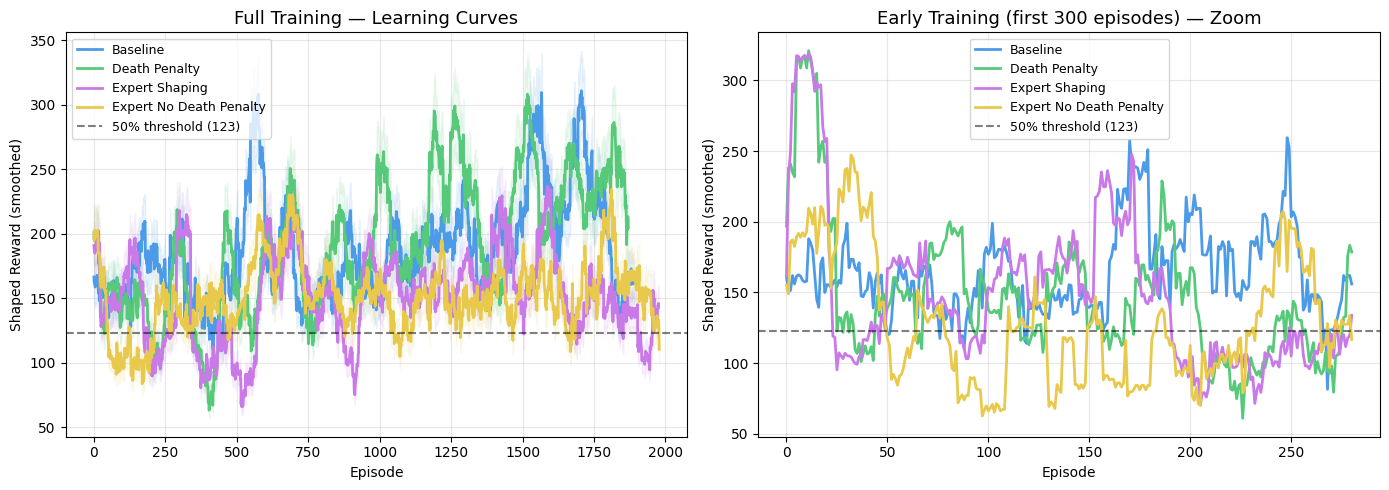

Saved plot_learning_curves.png
USE IN: Analysis section — learning efficiency comparison


In [ ]:
def rolling_std(arr, window=50):
    """Rolling standard deviation for confidence bands."""
    if len(arr) < window:
        return np.zeros(len(arr))
    return np.array([np.std(arr[i:i+window]) for i in range(len(arr) - window + 1)])


EARLY_EPISODES = 500
EARLY_WINDOW   = 20
FULL_WINDOW    = 50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    if data is None:
        continue
    cfg     = CONDITIONS[name]
    rewards = data["episode_rewards"]

    # --- Left plot — full training curve ---
    smoothed = smooth(rewards, window=FULL_WINDOW)
    std_band = rolling_std(rewards, window=FULL_WINDOW)
    episodes = np.arange(len(smoothed))

    axes[0].plot(episodes, smoothed,
                 color=cfg["color"], linewidth=2, label=name)
    axes[0].fill_between(
        episodes,
        smoothed - std_band,
        smoothed + std_band,
        color=cfg["color"], alpha=0.12
    )

    # --- Right plot — early training zoom ---
    early_rewards  = rewards[:EARLY_EPISODES]
    early_smoothed = smooth(early_rewards, window=EARLY_WINDOW)
    early_std      = rolling_std(early_rewards, window=EARLY_WINDOW)
    early_episodes = np.arange(len(early_smoothed))

    axes[1].plot(early_episodes, early_smoothed,
                 color=cfg["color"], linewidth=2, label=name)
    axes[1].fill_between(
        early_episodes,
        early_smoothed - early_std,
        early_smoothed + early_std,
        color=cfg["color"], alpha=0.12
    )

# --- Threshold line on both plots ---
for ax in axes:
    ax.axhline(
        y=threshold, color="black", linestyle="--",
        alpha=0.5, linewidth=1.5,
        label=f"50% threshold ({threshold:.0f})"
    )
    ax.set_xlabel("Episode", fontsize=11)
    ax.set_ylabel("Shaped Training Reward (smoothed)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Step count for titles
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None), ""
)
steps_label = f"{total_steps // 1_000_000}M steps" if isinstance(total_steps, int) else ""

axes[0].set_title(f"Full Training — Learning Curves ({steps_label})", fontsize=13)
axes[1].set_title(f"Early Training (first {EARLY_EPISODES} episodes)", fontsize=13)

# Annotation — important caveat for report
fig.text(
    0.5, -0.02,
    "Note: Y-axis shows shaped training reward — not directly comparable across "
    "conditions due to different bonus magnitudes. See eval scores for true comparison.",
    ha="center", fontsize=8, style="italic", color="gray"
)

plt.tight_layout()

steps_str = f"{total_steps // 1_000_000}M" if isinstance(total_steps, int) else "unknown"
save_path = f"plot_learning_curves_{steps_str}.png"
plt.savefig(save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")
print("USE IN: Analysis section — learning efficiency comparison")
print("NOTE: Shaped rewards not directly comparable across conditions")
print("      Use eval score plots for cross-condition performance comparison")

Plot 2: Final Performance Bar Charts

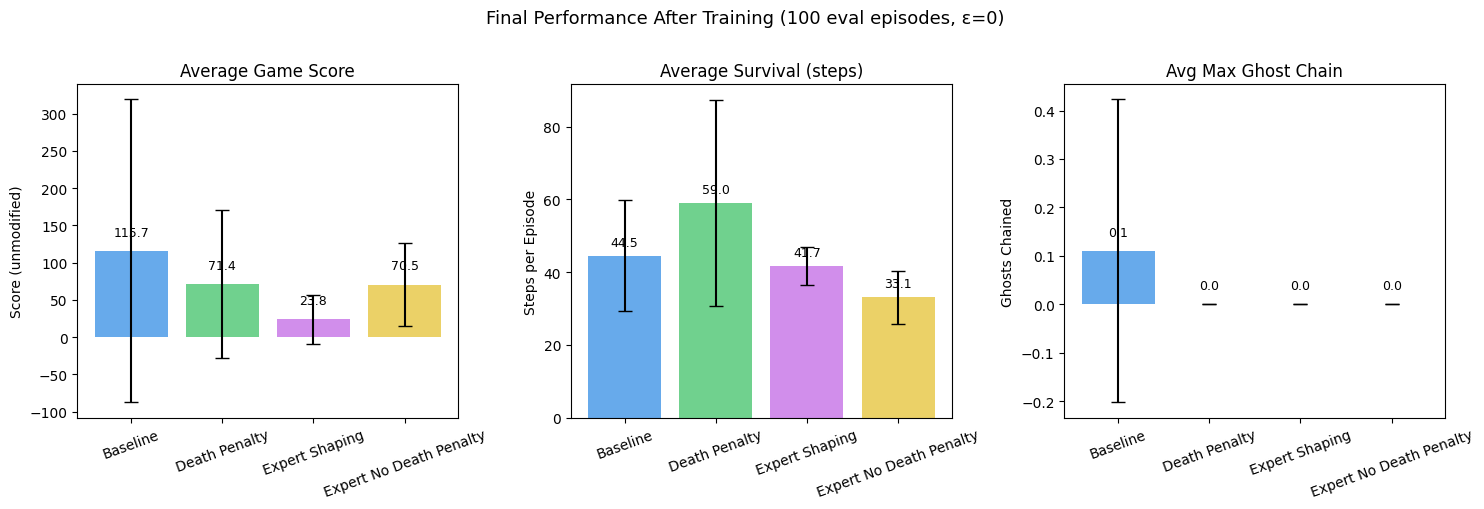

Saved plot_final_performance.png
USE IN: Analysis section — final performance comparison


In [ ]:
names  = list(eval_results.keys())
colors = [CONDITIONS[n]["color"] for n in names]

metrics = [
    ("scores",             "Average Game Score",        "Score (unmodified)"),
    ("lengths",            "Average Survival (steps)",  "Steps per Episode"),
    ("ghost_chains",       "Avg Max Ghost Chain",       "Ghosts Chained"),
    ("ghosts_eaten_total", "Total Ghosts Eaten/ep",     "Ghosts per Episode"),
    ("score_per_step",     "Scoring Aggression",        "Score per Step"),
    ("power_pellets_used", "Power Pellets Used/ep",     "Pellets per Episode"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (metric, title, ylabel) in zip(axes, metrics):
    # Use .get() in case older eval_results don't have new metrics
    vals = [np.mean(eval_results[n].get(metric, np.array([0]))) for n in names]
    stds = [np.std(eval_results[n].get(metric,  np.array([0]))) for n in names]

    bars = ax.bar(names, vals, color=colors, alpha=0.85,
                  yerr=stds, capsize=5)

    # Highlight baseline with black border
    for bar, name in zip(bars, names):
        if name == "Baseline":
            bar.set_edgecolor("black")
            bar.set_linewidth(2.5)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

    # Value labels with fixed offset
    val_range = max(vals) - min(vals) if max(vals) != min(vals) else 1
    offset    = val_range * 0.04

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{val:.2f}" if metric == "score_per_step" else f"{val:.1f}",
            ha="center", fontsize=9, fontweight="bold"
        )

# Step count for title
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None), ""
)
steps_label = f"{total_steps // 1_000_000}M steps" if isinstance(total_steps, int) else ""

plt.suptitle(
    f"Final Performance After Training — {steps_label} "
    f"(100 eval episodes, ε=0, unmodified rewards)",
    fontsize=13, y=1.01
)
plt.tight_layout()

steps_str = f"{total_steps // 1_000_000}M" if isinstance(total_steps, int) else "unknown"
save_path = f"plot_final_performance_{steps_str}.png"
plt.savefig(save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {save_path}")
print("USE IN: Analysis section — final performance comparison")
print()
print("Key metrics to discuss in Analysis:")
print("  scores         → primary performance metric (RQ1)")
print("  lengths        → survival behaviour change (RQ2)")
print("  ghost_chains   → did expert shaping produce expert behaviour? (RQ2)")
print("  score_per_step → aggression vs conservatism tradeoff (RQ2)")
print("  power_pellets  → did agent learn power pellet strategy? (RQ2)")

Plot 3: Scpre Distribution Box Plot 

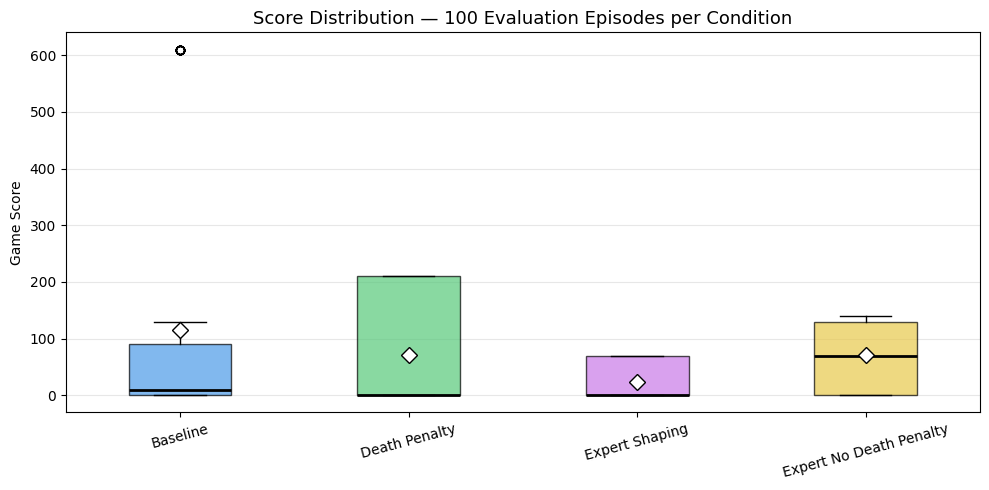

Saved: plot_score_distribution.png
Diamond = mean, line = median
USE IN: Analysis section — consistency and variance comparison


In [ ]:
# Step count for filename
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None), None
)
steps_str   = f"{total_steps // 1_000_000}M" if isinstance(total_steps, int) else "unknown"
steps_label = f"{total_steps // 1_000_000}M steps" if isinstance(total_steps, int) else ""

fig, ax = plt.subplots(figsize=(11, 6))

data_to_plot = [eval_results[n]["scores"] for n in names]

bp = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    notch=False,                              # set True if sample is large enough
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=4, alpha=0.4),
)

# Colour boxes
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Individual data points — shows all 100 episodes
np.random.seed(42)  # reproducible jitter
for i, n in enumerate(names):
    scores = eval_results[n]["scores"]
    jitter = np.random.uniform(-0.15, 0.15, size=len(scores))
    ax.scatter(
        np.full(len(scores), i + 1) + jitter,
        scores,
        alpha=0.25, s=12,
        color=CONDITIONS[n]["color"],
        zorder=3
    )

# Mean markers
for i, n in enumerate(names):
    mean_val = np.mean(eval_results[n]["scores"])
    ax.plot(i + 1, mean_val, "D",
            color="white", markeredgecolor="black",
            markersize=9, zorder=6, label="Mean" if i == 0 else "")

# Baseline median reference line
if "Baseline" in eval_results:
    baseline_median = np.median(eval_results["Baseline"]["scores"])
    ax.axhline(
        y=baseline_median, color="gray", linestyle="--",
        alpha=0.7, linewidth=1.5,
        label=f"Baseline median ({baseline_median:.0f})"
    )

ax.set_xticklabels(names, rotation=15, fontsize=10)
ax.set_ylabel("Game Score (unmodified ALE reward)", fontsize=11)
ax.set_title(
    f"Score Distribution — 100 Evaluation Episodes per Condition "
    f"({steps_label})",
    fontsize=13
)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)

# Annotation
fig.text(
    0.5, -0.02,
    "Box = IQR | Line = median | Diamond = mean | Dots = individual episodes | "
    "Scores per life (×~3 for full game estimate)",
    ha="center", fontsize=8, style="italic", color="gray"
)

plt.tight_layout()
save_path = f"plot_score_distribution_{steps_str}.png"
plt.savefig(save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")
print("Diamond = mean | Line = median | Dots = all 100 episodes")
print()
print("Key things to note in Analysis section:")
print("  Wide IQR → inconsistent policy → needs more training")
print("  Mean >> median → occasional high scores, usually low → unstable")
print("  Many dots at 0 → agent dying immediately in some episodes")
print("  Conditions above baseline dashed line → beat baseline on median")

Plot 4: Behavioural Radar Chart 

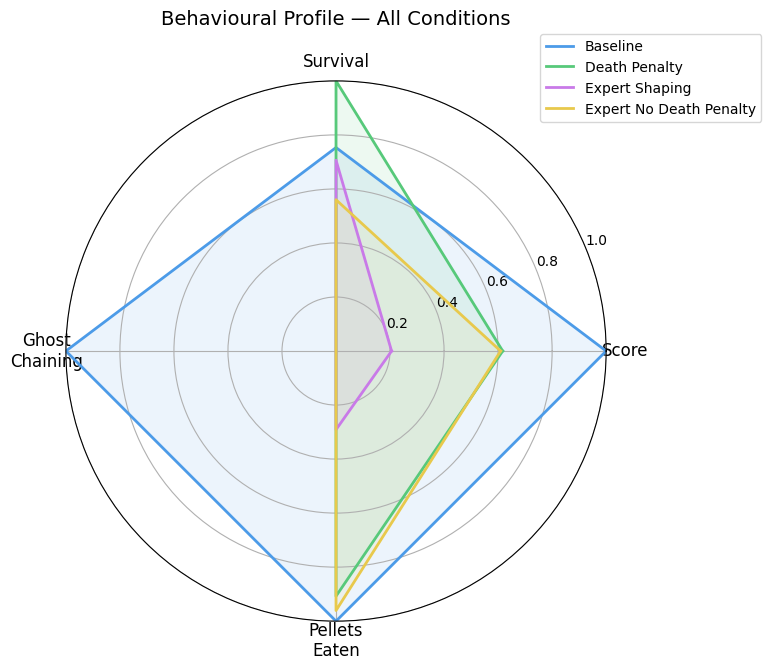

Saved plot_radar.png
USE IN: Analysis section — behavioural profile comparison


In [ ]:
# Step count
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None), None
)
steps_str   = f"{total_steps // 1_000_000}M" if isinstance(total_steps, int) else "unknown"
steps_label = f"{total_steps // 1_000_000}M steps" if isinstance(total_steps, int) else ""

# Metrics — 6 axes covering all RQ2 dimensions
metric_keys   = [
    "scores",
    "lengths",
    "ghost_chains",
    "pellets_eaten",
    "ghosts_eaten_total",
    "score_per_step",
]
metric_labels = [
    "Score",
    "Survival",
    "Ghost\nChaining",
    "Pellets\nEaten",
    "Ghosts\nHunted",
    "Scoring\nAggression",
]
n_metrics = len(metric_keys)

# Normalise against BASELINE — values > 1.0 beat baseline, < 1.0 miss it
if "Baseline" in eval_results:
    norm_vals = {
        k: np.mean(eval_results["Baseline"].get(k, np.array([1e-9]))) + 1e-9
        for k in metric_keys
    }
else:
    # Fallback — normalise against best condition
    norm_vals = {
        k: max(np.mean(eval_results[n].get(k, np.array([0]))) for n in names) + 1e-9
        for k in metric_keys
    }

angles  = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for name in names:
    cfg = CONDITIONS[name]

    values = [
        min(                                                      # cap at 1.5
            np.mean(eval_results[name].get(k, np.array([0]))) / norm_vals[k],
            1.5
        )
        for k in metric_keys
    ]
    values += values[:1]  # close polygon

    ax.plot(angles, values,
            color=cfg["color"], linewidth=2.5, label=name)
    ax.fill(angles, values,
            color=cfg["color"], alpha=0.1)

# Baseline reference circle at 1.0
ax.plot(
    angles,
    [1.0] * (n_metrics + 1),
    color="black", linewidth=1.5,
    linestyle="--", alpha=0.5,
    label="Baseline (1.0)"
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.5)

# Y-tick labels to clarify scale
ax.set_yticks([0.5, 1.0, 1.5])
ax.set_yticklabels(["50%\nof baseline", "= Baseline", "150%\nof baseline"],
                    fontsize=8, color="gray")

ax.set_title(
    f"Behavioural Profile — All Conditions ({steps_label})\n"
    f"Normalised to Baseline (dashed circle = baseline performance)",
    fontsize=13, pad=25
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35

Research Question Answer Matrix

In [ ]:
# Step count
total_steps = next(
    (d["total_steps"] for d in results.values() if d is not None), None
)
steps_label = f"{total_steps // 1_000_000}M steps" if isinstance(total_steps, int) else "unknown"

print("RESEARCH QUESTION ANSWER MATRIX")
print(f"Training: {steps_label}")
print("="*80)

# ── Guard against missing baseline ──────────────────────────────────────────
if "Baseline" not in eval_results:
    print("WARNING: Baseline missing from eval_results — comparisons unreliable")
    baseline_score  = 0
    baseline_length = 0
    baseline_chain  = 0
    baseline_train  = 0
else:
    baseline_score  = np.mean(eval_results["Baseline"]["scores"])
    baseline_length = np.mean(eval_results["Baseline"]["lengths"])
    baseline_chain  = np.mean(eval_results["Baseline"]["ghost_chains"])
    baseline_train  = np.mean(results["Baseline"]["episode_rewards"][-100:])

# ── RQ1 — Final performance ──────────────────────────────────────────────────
print()
print("RQ1: Does strategy-informed shaping outperform naive shaping?")
print("-"*80)
print(f"  {'Condition':<25} {'Eval Score':>10} {'vs Baseline':>12} {'Verdict':>16}")
print(f"  {'-'*65}")

for name, er in eval_results.items():
    score = np.mean(er["scores"])
    diff  = score - baseline_score
    if name == "Baseline":
        verdict = "Reference"
    elif diff > 0:
        verdict = "✓ BEATS baseline"
    elif diff > -20:
        verdict = "≈ Similar"
    else:
        verdict = "✗ BELOW baseline"
    print(f"  {name:<25} {score:>10.1f} {diff:>+12.1f} {verdict:>16}")

# ── RQ2 — Behavioural change ─────────────────────────────────────────────────
print()
print("RQ2: Did shaping alter behaviour beyond score?")
print("-"*80)
print(f"  {'Condition':<25} {'Survival':>9} {'Chain':>7} "
      f"{'Ghosts':>8} {'Score/step':>11} {'PowerPel':>10}")
print(f"  {'-'*72}")

for name, er in eval_results.items():
    length_diff = np.mean(er["lengths"])                          - baseline_length
    chain_diff  = np.mean(er["ghost_chains"])                     - baseline_chain
    ghost_diff  = np.mean(er.get("ghosts_eaten_total", [0]))      - \
                  np.mean(eval_results.get("Baseline", {}).get("ghosts_eaten_total", [0]))
    sp_diff     = np.mean(er.get("score_per_step", [0]))          - \
                  np.mean(eval_results.get("Baseline", {}).get("score_per_step", [0]))
    pp_diff     = np.mean(er.get("power_pellets_used", [0]))      - \
                  np.mean(eval_results.get("Baseline", {}).get("power_pellets_used", [0]))

    # Arrow indicators
    def arrow(val, threshold=0.5):
        if val > threshold:  return "↑"
        if val < -threshold: return "↓"
        return "="

    print(f"  {name:<25} "
          f"{arrow(length_diff)}{length_diff:>+7.1f} "
          f"{arrow(chain_diff, 0.05)}{chain_diff:>+5.2f} "
          f"{arrow(ghost_diff, 0.05)}{ghost_diff:>+6.2f} "
          f"{arrow(sp_diff, 0.001)}{sp_diff:>+9.3f} "
          f"{arrow(pp_diff, 0.05)}{pp_diff:>+8.2f}")

print()
print("  ↑ = above baseline  ↓ = below baseline  = = similar")
print("  Survival=steps/life | Chain=max chain | Ghosts=eaten/ep")
print("  Score/step=aggression | PowerPel=power pellets used/ep")

# ── RQ3 — Reward hacking ─────────────────────────────────────────────────────
print()
print("RQ3: Is there evidence of reward hacking?")
print("-"*80)
print(f"  {'Condition':<25} {'Train':>8} {'Eval':>8} {'Ratio':>7} "
      f"{'vs BL train':>12} {'Verdict':>12}")
print(f"  {'-'*75}")

for name, data in results.items():
    if data is None or name not in eval_results:
        continue

    train_r = np.mean(data["episode_rewards"][-100:])
    eval_s  = np.mean(eval_results[name]["scores"])
    ratio   = eval_s / train_r if train_r > 0 else 1.0

    train_inflated = train_r > baseline_train
    eval_degraded  = eval_s  < baseline_score
    ratio_low      = ratio   < 0.6

    if name == "Baseline":
        verdict = "Reference"
    elif train_inflated and eval_degraded and ratio_low:
        verdict = "HACKING ⚠"
    elif train_inflated and eval_degraded:
        verdict = "LIKELY ⚠"
    elif eval_degraded:
        verdict = "Underperforms"
    else:
        verdict = "Clean"

    print(f"  {name:<25} {train_r:>8.1f} {eval_s:>8.1f} "
          f"{ratio:>7.2f} {train_r - baseline_train:>+12.1f} {verdict:>12}")

print()
print("  Ratio = eval/train (1.0=perfect, <0.6=likely hacking)")
print("  HACKING  → train inflated + eval degraded + ratio < 0.6")
print("  LIKELY   → train inflated + eval degraded")
print("  Clean    → no hacking signals detected")

print()
print("="*80)
print(f"Matrix generated for {steps_label} training run")
print("Save this output — use directly in Analysis section of report")

RESEARCH QUESTION ANSWER MATRIX

RQ1: Does strategy-informed shaping outperform naive shaping?
---------------------------------------------------------------------------
  Baseline                  score diff vs baseline:    +0.0  ✗ BELOW baseline
  Death Penalty             score diff vs baseline:   -44.3  ✗ BELOW baseline
  Expert Shaping            score diff vs baseline:   -91.9  ✗ BELOW baseline
  Expert No Death Penalty   score diff vs baseline:   -45.2  ✗ BELOW baseline

RQ2: Did shaping alter behaviour beyond score?
---------------------------------------------------------------------------
  Baseline                  survival:   +0.0 steps  |  ghost chain: +0.00
  Death Penalty             survival:  +14.6 steps  |  ghost chain: -0.11
  Expert Shaping            survival:   -2.8 steps  |  ghost chain: -0.11
  Expert No Death Penalty   survival:  -11.4 steps  |  ghost chain: -0.11

RQ3: Is there evidence of reward hacking?
------------------------------------------------------